## Pulling the Data

In [147]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [148]:
# Imports
import oracledb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import altair as alt
import seaborn as sns

In [122]:
# Connecting to our database

dsn = oracledb.makedsn("localhost", 1522, service_name="stu")
connection = oracledb.connect(user="ora_inigogrc", password="a77155190", dsn=dsn)

In [126]:
# Inspecting our parent table
cur = connection.cursor()
cur.execute("SELECT * FROM parent_table")
rows = cur.fetchall()  # fetch all rows as a list of tuples

# Extract column names from the cursor description
col_names = [desc[0] for desc in cur.description]
cur.close()

# Create a DataFrame with the rows and the column names
parent_df = pd.DataFrame(rows, columns=col_names)
print(parent_df.info())
parent_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   AGE     43 non-null     int64 
 1   SEX     43 non-null     object
dtypes: int64(1), object(1)
memory usage: 820.0+ bytes
None


,AGE,SEX
0,19,Female
1,19,Male
2,20,Female
3,20,Male
4,21,Female


In [127]:
# Inspecting our social media table
cur = connection.cursor()
cur.execute("SELECT * FROM social_media_table")
rows = cur.fetchall()  # fetch all rows as a list of tuples

# Extract column names from the cursor description
col_names = [desc[0] for desc in cur.description]
cur.close()

# Create a DataFrame with the rows and the column names
social_media_df = pd.DataFrame(rows, columns=col_names)
print(social_media_df.info())
social_media_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 613 entries, 0 to 612
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   UNIQUE_ID       613 non-null    int64  
 1   AGE             613 non-null    int64  
 2   SEX             613 non-null    object 
 3   SNS_USE_LENGTH  613 non-null    float64
 4   SNS_USE_DAILY   613 non-null    float64
 5   SNS_USE_CASE    613 non-null    int64  
 6   SNS_FRIENDS     613 non-null    int64  
 7   SNS_PERSONAL    613 non-null    int64  
 8   SNS_CONTENT     613 non-null    object 
 9   SNS_GOOD        613 non-null    int64  
 10  SNS_BELIEVE     613 non-null    int64  
 11  PEER_PRESSURE   613 non-null    int64  
 12  SNS_INFLUENCE   613 non-null    float64
 13  SNS_WELLBEING   613 non-null    int64  
dtypes: float64(3), int64(9), object(2)
memory usage: 67.2+ KB
None


,UNIQUE_ID,AGE,SEX,SNS_USE_LENGTH,SNS_USE_DAILY,SNS_USE_CASE,SNS_FRIENDS,SNS_PERSONAL,SNS_CONTENT,SNS_GOOD,SNS_BELIEVE,PEER_PRESSURE,SNS_INFLUENCE,SNS_WELLBEING
0,1,26,Female,7.5,2.0,12,250,4,To stay connected with people,1,0,0,0.5,0
1,2,24,Female,7.5,6.0,12,1250,4,To stay connected with people,1,0,0,0.5,1
2,3,23,Female,1.0,6.0,22,3000,3,For time pass,1,1,1,0.5,1
3,4,27,Female,7.5,2.0,12,1250,3,For time pass,1,0,1,0.5,0
4,5,19,Male,3.5,4.0,22,1250,2,To make new friends,1,1,0,0.0,0


In [128]:
# Inspecting our social media table
cur = connection.cursor()
cur.execute("SELECT * FROM mental_health_table")
rows = cur.fetchall()  # fetch all rows as a list of tuples

# Extract column names from the cursor description
col_names = [desc[0] for desc in cur.description]
cur.close()

# Create a DataFrame with the rows and the column names
mental_health_df = pd.DataFrame(rows, columns=col_names)
print(mental_health_df.info())
mental_health_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   UNIQUE_ID               567 non-null    int64  
 1   AGE                     567 non-null    int64  
 2   SEX                     567 non-null    object 
 3   GENERAL_HEALTH          567 non-null    int64  
 4   PHQ_SCORE               567 non-null    int64  
 5   GAD7_SCORE              567 non-null    int64  
 6   HOPELESS                567 non-null    float64
 7   OVERWHELMED             567 non-null    float64
 8   EXHAUSTED               567 non-null    float64
 9   SAD                     567 non-null    float64
 10  RLY_SAD                 567 non-null    float64
 11  CONSIDERED              567 non-null    float64
 12  ATTEMPTED               567 non-null    float64
 13  DEPRESSION_DIAGNOSIS    567 non-null    int64  
 14  THERAPY                 567 non-null    in

,UNIQUE_ID,AGE,SEX,GENERAL_HEALTH,PHQ_SCORE,GAD7_SCORE,HOPELESS,OVERWHELMED,EXHAUSTED,SAD,RLY_SAD,CONSIDERED,ATTEMPTED,DEPRESSION_DIAGNOSIS,THERAPY,DEPRESSION_MEDICATION,ACHA_12MONTHS_ANY_COMP,STUDENT
0,1,22,Female,4,6,0,0.0,12.5,5.5,3.5,0.0,0.0,0.0,0,0,0,2,1
1,2,21,Female,3,19,4,1.5,5.5,7.5,1.5,1.5,1.5,0.0,0,0,0,0,1
2,3,23,Female,3,10,9,7.5,12.5,12.5,9.5,1.5,0.0,0.0,0,0,0,2,1
3,4,24,Female,3,11,10,9.5,9.5,7.5,12.5,3.5,0.0,0.0,0,0,0,2,1
4,5,22,Female,4,6,18,7.5,3.5,9.5,12.5,1.5,0.0,0.0,0,0,0,5,1


## Conducting Data Analysis

In [194]:
# Query for aggregates
aggregate_query = """
WITH mh_agg AS (
  SELECT 
    age,
    sex,
    COUNT(unique_id) AS mh_count,
    AVG(phq_score) AS avg_phq_score,
    AVG(gad7_score) AS avg_gad7_score,
    AVG(hopeless) AS avg_hopeless,
    AVG(overwhelmed) AS avg_overwhelmed,
    AVG(exhausted) AS avg_exhausted,
    AVG(sad) AS avg_sad,
    AVG(rly_sad) AS avg_rly_sad,
    AVG(considered) AS avg_considered,
    AVG(attempted) AS avg_attempted,
    AVG(depression_diagnosis) AS pct_diagnosed
  FROM mental_health_table
  GROUP BY age, sex
),
sm_agg AS (
  SELECT 
    age,
    sex,
    COUNT(unique_id) AS sm_count,
    AVG(sns_use_length) AS avg_sns_use_length,
    AVG(sns_use_daily) AS avg_sns_use_daily,
    AVG(sns_use_case) AS avg_sns_use_case,
    AVG(sns_friends) AS avg_sns_friends,
    AVG(sns_personal) AS avg_sns_personal,
    AVG(CASE WHEN sns_good = 1 THEN 1 ELSE 0 END) AS pct_sns_good,
    AVG(CASE WHEN sns_believe = 1 THEN 1 ELSE 0 END) AS pct_sns_believe,
    AVG(peer_pressure) AS pct_peer_pressure,
    AVG(sns_influence) AS pct_sns_influence,
    AVG(sns_wellbeing) AS pct_sns_wellbeing
  FROM social_media_table
  GROUP BY age, sex
)
SELECT 
  COALESCE(mh.age, sm.age) AS age,
  COALESCE(mh.sex, sm.sex) AS sex,
  mh.mh_count, sm.sm_count, mh.avg_phq_score, mh.avg_gad7_score, mh.avg_hopeless, 
  mh.avg_overwhelmed, mh.avg_exhausted, mh.avg_sad, mh.avg_rly_sad, mh.avg_considered, 
  mh.avg_attempted, mh.pct_diagnosed, sm.avg_sns_use_length, sm.avg_sns_use_daily,
  sm.avg_sns_use_case, sm.avg_sns_friends, sm.avg_sns_personal, sm.pct_sns_good,
  sm.pct_sns_believe, sm.pct_peer_pressure, sm.pct_sns_influence, sm.pct_sns_wellbeing
FROM mh_agg mh
FULL OUTER JOIN sm_agg sm
  ON mh.age = sm.age
 AND mh.sex = sm.sex
ORDER BY age, sex
"""

cur = connection.cursor()
cur.execute(aggregate_query)

# Fetch rows and columns and create df
rows = cur.fetchall()
col_names = [desc[0] for desc in cur.description]
cur.close()
aggregate_query_df = pd.DataFrame(rows, columns=col_names)
aggregate_query_df

,AGE,SEX,MH_COUNT,SM_COUNT,AVG_PHQ_SCORE,AVG_GAD7_SCORE,AVG_HOPELESS,AVG_OVERWHELMED,AVG_EXHAUSTED,AVG_SAD,...,AVG_SNS_USE_LENGTH,AVG_SNS_USE_DAILY,AVG_SNS_USE_CASE,AVG_SNS_FRIENDS,AVG_SNS_PERSONAL,PCT_SNS_GOOD,PCT_SNS_BELIEVE,PCT_PEER_PRESSURE,PCT_SNS_INFLUENCE,PCT_SNS_WELLBEING
0,19,Female,36,14,9.111111,10.000000,5.319444,10.277778,9.833333,7.888889,...,3.357143,3.035714,14.428571,1089.285714,2.071429,0.785714,0.785714,0.714286,0.607143,0.928571
1,19,Male,11,25,8.636364,4.181818,2.818182,5.545455,5.954545,3.545455,...,2.980000,2.880000,15.040000,1370.000000,2.040000,0.840000,0.800000,0.640000,0.380000,0.680000
2,20,Female,57,11,10.561404,7.947368,5.342105,9.324561,8.728070,6.368421,...,3.909091,2.454545,13.636364,613.636364,2.454545,1.000000,0.272727,0.181818,0.454545,0.727273
3,20,Male,31,23,10.645161,5.741935,4.225806,7.177419,6.822581,5.306452,...,5.195652,3.108696,13.565217,1097.826087,2.130435,0.869565,0.608696,0.739130,0.456522,0.739130
4,21,Female,68,9,10.500000,9.720588,5.779412,9.308824,9.316176,7.007353,...,6.166667,3.388889,12.444444,1111.111111,2.666667,0.777778,0.222222,0.666667,0.444444,0.555556
5,21,Male,36,18,6.666667,7.833333,5.402778,7.750000,6.972222,5.555556,...,4.944444,2.666667,14.888889,847.222222,2.222222,0.888889,0.555556,0.500000,0.527778,0.444444
6,22,Female,97,23,9.195876,9.536082,6.489691,10.123711,9.932990,8.231959,...,5.304348,4.782609,12.956522,1434.782609,2.652174,0.869565,0.173913,0.434783,0.478261,0.434783
7,22,Male,36,19,8.166667,7.472222,5.305556,8.194444,8.625000,5.763889,...,6.500000,2.815789,15.473684,1276.315789,2.526316,0.894737,0.157895,0.526316,0.394737,0.684211
8,23,Female,37,24,7.189189,8.945946,5.891892,7.581081,7.216216,6.770270,...,5.395833,4.020833,14.500000,697.916667,2.416667,0.833333,0.333333,0.666667,0.458333,0.666667
9,23,Male,19,29,8.526316,5.789474,4.289474,6.421053,6.973684,6.131579,...,7.689655,3.568966,15.655172,1120.689655,2.655172,0.931034,0.172414,0.517241,0.465517,0.482759


In [195]:
group_by_age = aggregate_query_df.groupby("AGE").mean(numeric_only=True).reset_index()
print("Aggregates by AGE:")
group_by_age

Aggregates by AGE:


,AGE,MH_COUNT,SM_COUNT,AVG_PHQ_SCORE,AVG_GAD7_SCORE,AVG_HOPELESS,AVG_OVERWHELMED,AVG_EXHAUSTED,AVG_SAD,AVG_RLY_SAD,...,AVG_SNS_USE_LENGTH,AVG_SNS_USE_DAILY,AVG_SNS_USE_CASE,AVG_SNS_FRIENDS,AVG_SNS_PERSONAL,PCT_SNS_GOOD,PCT_SNS_BELIEVE,PCT_PEER_PRESSURE,PCT_SNS_INFLUENCE,PCT_SNS_WELLBEING
0,19,23.5,19.5,8.873737,7.090909,4.068813,7.911616,7.893939,5.717172,3.257576,...,3.168571,2.957857,14.734286,1229.642857,2.055714,0.812857,0.792857,0.677143,0.493571,0.804286
1,20,44.0,17.0,10.603282,6.844652,4.783956,8.250990,7.775325,5.837436,4.028721,...,4.552372,2.781621,13.600791,855.731225,2.292490,0.934783,0.440711,0.460474,0.455534,0.733202
2,21,52.0,13.5,8.583333,8.776961,5.591095,8.529412,8.144199,6.281454,4.608660,...,5.555556,3.027778,13.666667,979.166667,2.444444,0.833333,0.388889,0.583333,0.486111,0.500000
3,22,66.5,21.0,8.681271,8.504152,5.897623,9.159078,9.278995,6.997924,5.158219,...,5.902174,3.799199,14.215103,1355.549199,2.589245,0.882151,0.165904,0.480549,0.436499,0.559497
4,23,28.0,26.5,7.857752,7.367710,5.090683,7.001067,7.094950,6.450925,4.808677,...,6.542744,3.794899,15.077586,909.303161,2.535920,0.882184,0.252874,0.591954,0.461925,0.574713
5,24,14.0,29.5,7.404762,8.142857,5.238095,6.976190,6.547619,5.726190,4.869048,...,7.094840,3.303416,13.601744,1234.193314,2.470203,0.809593,0.128634,0.416424,0.470930,0.642442
6,25,9.0,48.0,11.208333,6.583333,3.979167,7.354167,6.416667,7.333333,4.437500,...,7.645455,3.378788,14.596970,948.863636,2.495455,0.830303,0.153030,0.460606,0.449242,0.596970
7,26,6.5,46.5,11.678571,4.916667,4.654762,7.452381,6.696429,5.875000,3.910714,...,8.115882,3.157206,14.103529,1112.867647,2.579412,0.749706,0.102059,0.564706,0.435294,0.670882
8,27,4.0,32.5,7.083333,7.583333,6.291667,8.208333,8.083333,7.875000,5.083333,...,7.615278,3.066667,14.022222,1081.944444,2.686111,0.752778,0.183333,0.597222,0.493056,0.550000
9,28,6.0,16.0,12.444444,7.277778,5.361111,5.972222,7.000000,5.472222,3.777778,...,7.953125,3.796875,13.250000,1195.312500,2.500000,0.656250,0.156250,0.531250,0.578125,0.687500


In [196]:
group_by_sex = aggregate_query_df.groupby("SEX").mean(numeric_only=True).reset_index()
print("Aggregates by AGE:")
group_by_sex

Aggregates by AGE:


,SEX,AGE,MH_COUNT,SM_COUNT,AVG_PHQ_SCORE,AVG_GAD7_SCORE,AVG_HOPELESS,AVG_OVERWHELMED,AVG_EXHAUSTED,AVG_SAD,...,AVG_SNS_USE_LENGTH,AVG_SNS_USE_DAILY,AVG_SNS_USE_CASE,AVG_SNS_FRIENDS,AVG_SNS_PERSONAL,PCT_SNS_GOOD,PCT_SNS_BELIEVE,PCT_PEER_PRESSURE,PCT_SNS_INFLUENCE,PCT_SNS_WELLBEING
0,Female,29.700000,19.200000,17.70000,9.802681,9.151944,5.934381,9.205401,8.630804,7.442412,...,5.825359,2.733791,14.027504,821.552099,2.199049,0.692718,0.282119,0.392524,0.421646,0.71291
1,Male,31.086957,7.956522,11.26087,9.713695,6.305164,4.855854,6.916368,6.523413,5.559496,...,7.699443,2.914304,14.052054,1496.803838,2.618959,0.763155,0.287621,0.504998,0.493252,0.54844


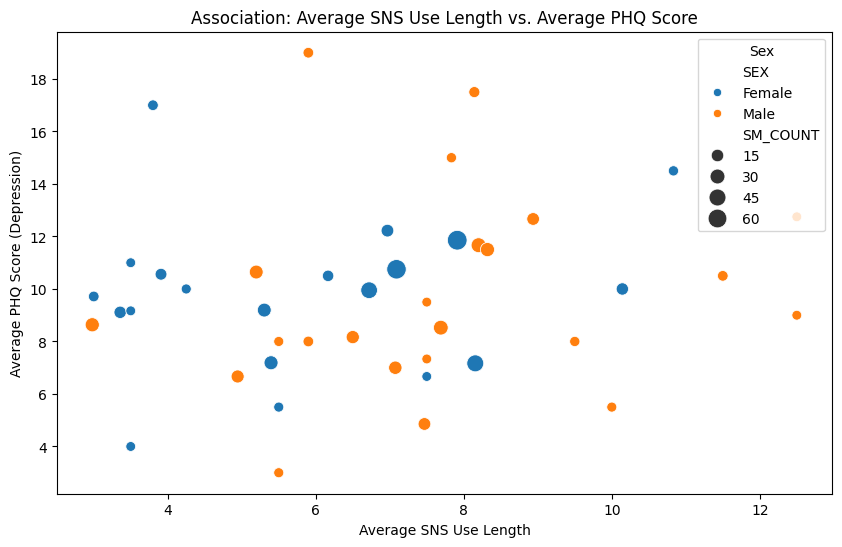

In [197]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=aggregate_query_df, 
                x='AVG_SNS_USE_LENGTH', 
                y='AVG_PHQ_SCORE', 
                hue='SEX', 
                size='SM_COUNT', 
                sizes=(50, 200))
plt.title("Association: Average SNS Use Length vs. Average PHQ Score")
plt.xlabel("Average SNS Use Length")
plt.ylabel("Average PHQ Score (Depression)")
plt.legend(title="Sex")
plt.show()


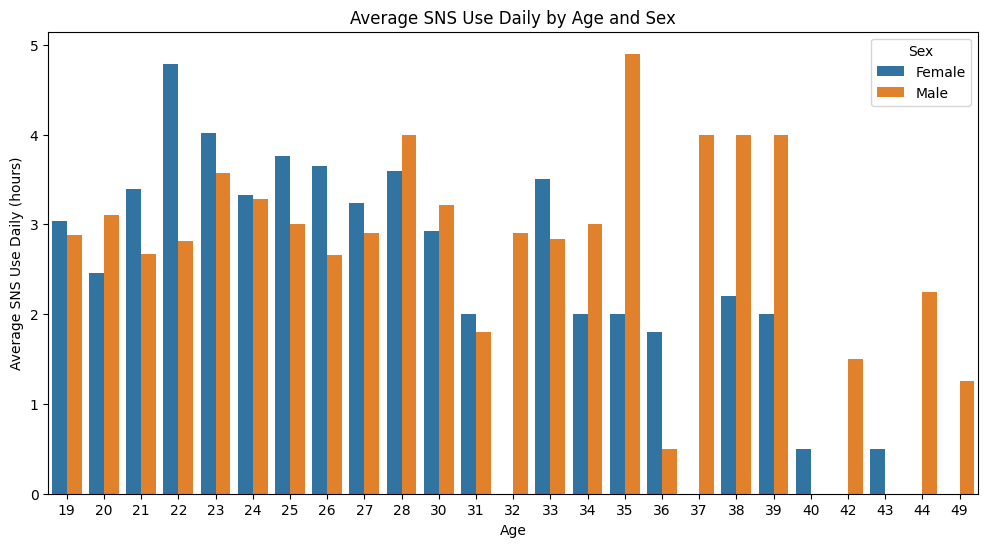

In [153]:
plt.figure(figsize=(12,6))
sns.barplot(data=aggregate_query_df.sort_values("AGE"), 
            x="AGE", 
            y="AVG_SNS_USE_DAILY", 
            hue="SEX")
plt.title("Average SNS Use Daily by Age and Sex")
plt.xlabel("Age")
plt.ylabel("Average SNS Use Daily (hours)")
plt.legend(title="Sex")
plt.show()

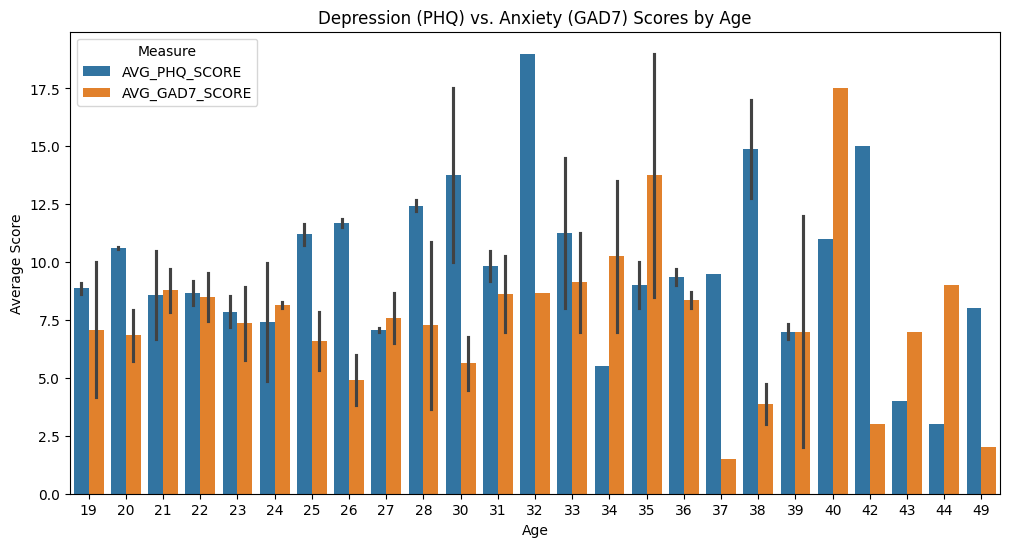

In [154]:
plt.figure(figsize=(12,6))
# Melt the data so that avg_phq_score and avg_gad7_score become two rows per group:
melted = aggregate_query_df.melt(id_vars=['AGE', 'SEX'], 
                          value_vars=['AVG_PHQ_SCORE', 'AVG_GAD7_SCORE'],
                          var_name='MEASURE', value_name='SCORE')

sns.barplot(data=melted, 
            x="AGE", 
            y="SCORE", 
            hue="MEASURE")
plt.title("Depression (PHQ) vs. Anxiety (GAD7) Scores by Age")
plt.xlabel("Age")
plt.ylabel("Average Score")
plt.legend(title="Measure")
plt.show()

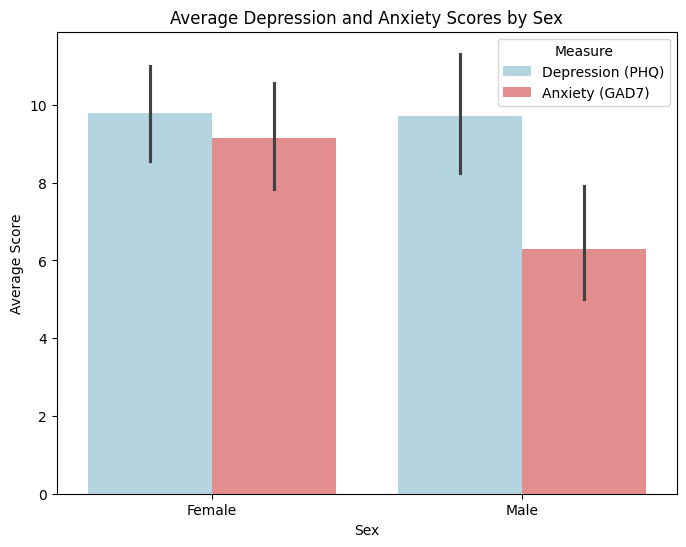

In [160]:
melted_df = aggregate_query_df.melt(
    id_vars=['SEX'],
    value_vars=['AVG_PHQ_SCORE', 'AVG_GAD7_SCORE'],
    var_name='MEASURE',
    value_name='SCORE'
)

palette_dict = {
    "AVG_PHQ_SCORE": "lightblue",
    "AVG_GAD7_SCORE": "lightcoral"
}

plt.figure(figsize=(8,6))

sns.barplot(
    data=melted_df,
    x="SEX",
    y="SCORE",
    hue="MEASURE",
    palette=palette_dict,
    hue_order=["AVG_PHQ_SCORE", "AVG_GAD7_SCORE"] 
)

plt.title("Average Depression and Anxiety Scores by Sex")
plt.xlabel("Sex")
plt.ylabel("Average Score")
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=["Depression (PHQ)", "Anxiety (GAD7)"], title="Measure")
plt.show()

In [229]:
metrics = [
    "AVG_SNS_USE_LENGTH",
    "AVG_SNS_USE_DAILY",
    "PCT_SNS_BELIEVE",
    "PCT_PEER_PRESSURE",
    "PCT_SNS_INFLUENCE",
    "PCT_SNS_WELLBEING"
]

chart_1 = alt.Chart(aggregate_query_df).mark_point().encode(
    x=alt.X("AGE:Q", title="Age", scale=alt.Scale(zero=False)),
    y=alt.Y(alt.repeat("row"), type="quantitative"),
    size=alt.Size("MH_COUNT:Q", title="Count"),
    color=alt.Color("SEX:N", title="Sex")
).properties(
    width=400,
    height=150
).repeat(
    row=metrics  # One column of facets, one facet per metric
)
chart_1

alt.RepeatChart(...)

In [240]:
# metrics = [
#     "AVG_SNS_USE_LENGTH",
#     "AVG_SNS_USE_DAILY",
#     "PCT_SNS_BELIEVE",
#     "PCT_PEER_PRESSURE",
#     "PCT_SNS_INFLUENCE",
#     "PCT_SNS_WELLBEING"
# ]
# melted_df = aggregate_query_df.melt(
#     id_vars=["SEX"],     
#     value_vars=metrics,    
#     var_name="METRIC",     
#     value_name="VALUE"     
# )

# chart_2 = (
#     alt.Chart(melted_df)
#     .mark_bar()
#     .encode(
#         x=alt.X("SEX:N", title="Sex"),
#         y=alt.Y("mean(VALUE):Q", title="Average Value"),
#         color=alt.Color("SEX:N", legend=None),
#         tooltip=["SEX:N", alt.Tooltip("mean(VALUE):Q", title="Average Value")]
#     )
#     .facet(
#         row="METRIC",    
#     )
# )
# chart_2

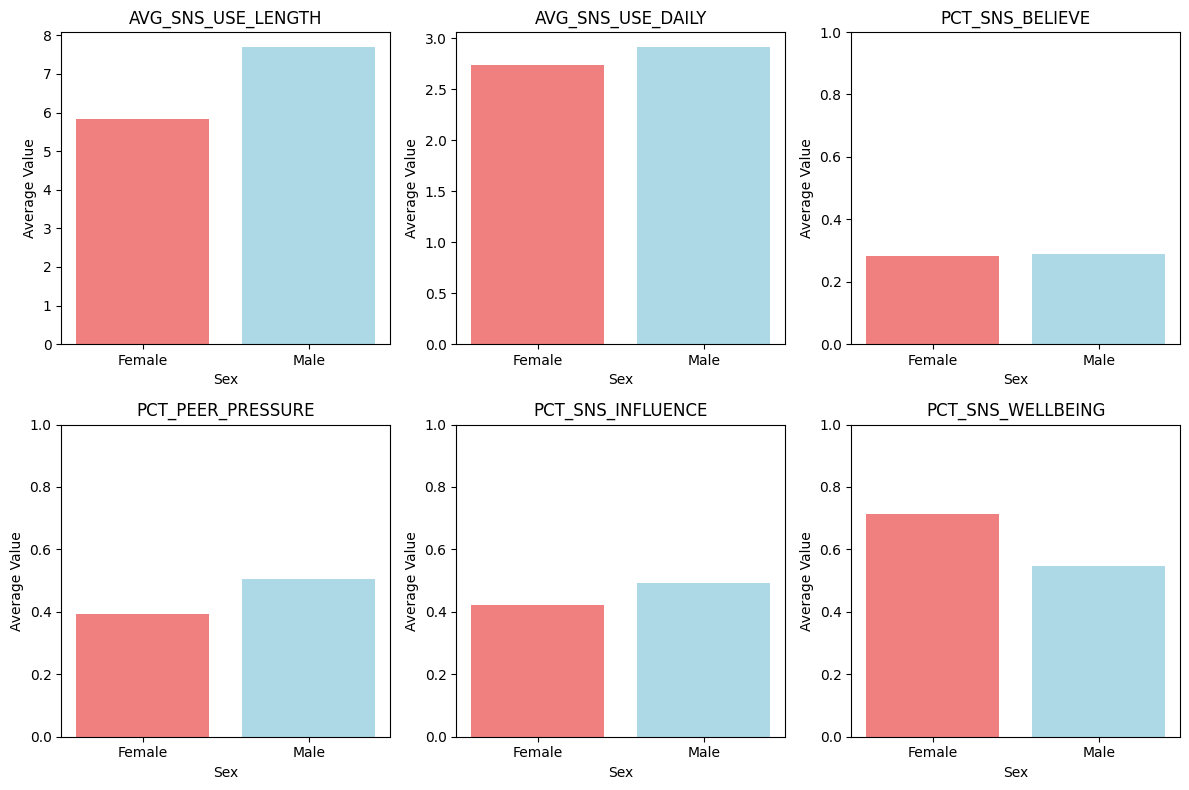

In [239]:
metrics = [
    "AVG_SNS_USE_LENGTH",
    "AVG_SNS_USE_DAILY",
    "PCT_SNS_BELIEVE",
    "PCT_PEER_PRESSURE",
    "PCT_SNS_INFLUENCE",
    "PCT_SNS_WELLBEING"
]
group_by_sex = aggregate_query_df.groupby("SEX").mean().reset_index()
# Subplots
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
axs = axs.flatten()  # For iteration

for i, metric in enumerate(metrics):
    ax = axs[i]
    sexes = group_by_sex["SEX"]
    values = group_by_sex[metric]
    colors = ['lightcoral' if sex.lower() == "female" else 'lightblue' for sex in sexes]
    
    ax.bar(sexes, values, color=colors)
    ax.set_title(metric)
    ax.set_xlabel("Sex")
    ax.set_ylabel("Average Value")
    # Forcing y-axis to 0-1 for percentages
    if metric.startswith("PCT_"):
        ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [226]:
metrics = ['AVG_SNS_USE_LENGTH', 'AVG_SNS_USE_DAILY', 'PCT_SNS_BELIEVE', 'PCT_PEER_PRESSURE', 'PCT_SNS_INFLUENCE', 'PCT_SNS_WELLBEING']
scores = ['AVG_PHQ_SCORE', 'AVG_GAD7_SCORE', 'PCT_DIAGNOSED']

chart_3 = alt.Chart(aggregate_query_df).mark_circle().encode(
    alt.X(alt.repeat('row'), type='quantitative'),
    alt.Y(alt.repeat('column'), type='quantitative'),
    color='AGE:Q',       
    size='SM_COUNT:Q'     
).properties(
    height=150
).repeat(
    row=metrics,    
    column=scores   
)
chart_3

alt.RepeatChart(...)